In [2]:
import pandas as pd
from matplotlib import pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder,StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense,BatchNormalization,Dropout

In [ ]:
#                           RAINFALL CATEGORICAL DATASET

In [3]:
df=pd.read_csv(r'C:\Users\amank\Downloads\DEEP LEARNING ANN\Rainfall.csv')
df.head()

,day,pressure,maxtemp,temparature,mintemp,dewpoint,humidity,cloud,rainfall,sunshine,winddirection,windspeed
0,1,1025.9,19.9,18.3,16.8,13.1,72,49,yes,9.3,80.0,26.3
1,2,1022.0,21.7,18.9,17.2,15.6,81,83,yes,0.6,50.0,15.3
2,3,1019.7,20.3,19.3,18.0,18.4,95,91,yes,0.0,40.0,14.2
3,4,1018.9,22.3,20.6,19.1,18.8,90,88,yes,1.0,50.0,16.9
4,5,1015.9,21.3,20.7,20.2,19.9,95,81,yes,0.0,40.0,13.7


In [4]:
df.drop(columns=['day'],inplace=True)

In [7]:
df.isnull().sum()

pressure                  0
maxtemp                   0
temparature               0
mintemp                   0
dewpoint                  0
humidity                  0
cloud                     0
rainfall                  0
sunshine                  0
         winddirection    0
windspeed                 0
dtype: int64

In [6]:
df.dropna(inplace=True)

In [8]:
X = df.drop(columns=['rainfall'])
y = df['rainfall']

In [ ]:
label = LabelEncoder()

y = label.fit_transform(y)

In [ ]:
print(y[:10])

[1 1 1 1 1 1 0 0 0 1]


In [20]:
X_train,x_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [21]:
X.shape,y.shape

((365, 10), (365,))

In [22]:
model=Sequential()

In [32]:
model.add(Dense(512,activation='relu',input_dim=(9)))
model.add(Dropout(0.1))

model.add(Dense(256,activation='relu'))  # CAN DO THIS WAS AS WELL  model.add(Dense(128)) SELECT RELU DEFAULT.
model.add(Dropout(0.1))

model.add(Dense(128,activation='relu'))
model.add(Dropout(0.2))

model.add(Dense(64,activation='relu'))

model.add(Dense(1,activation='sigmoid'))

c:\Users\amank\Downloads\DEEP LEARNING ANN\.Deelearn\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [33]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            17 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 512)            │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 184,326 (720.03 KB)

 Trainable params: 177,090 (691.76 KB)

 Non-trainable params: 192 (768.00 B)

 Optimizer params: 7,044 (27.52 KB)

In [34]:
model.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])

In [35]:
history=model.fit(X_train,y_train,batch_size=32,epochs=50,validation_split=0.2)

Epoch 1/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 39s 205ms/step - accuracy: 0.6438 - loss: 0.6158 - val_accuracy: 0.7119 - val_loss: 0.4817
Epoch 2/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.6481 - loss: 0.5283 - val_accuracy: 0.7119 - val_loss: 0.4086
Epoch 3/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.6481 - loss: 0.4999 - val_accuracy: 0.7119 - val_loss: 0.3809
Epoch 4/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 179ms/step - accuracy: 0.7897 - loss: 0.4883 - val_accuracy: 0.8644 - val_loss: 0.3903
Epoch 5/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 89ms/step - accuracy: 0.8412 - loss: 0.4867 - val_accuracy: 0.8644 - val_loss: 0.3598
Epoch 6/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 99ms/step - accuracy: 0.8240 - loss: 0.4729 - val_accuracy: 0.8814 - val_loss: 0.3932
Epoch 7/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 186ms/step - accuracy: 0.8155 - loss: 0.4713 - val_accuracy: 0.8814 - val_loss: 0.3582
Epoch 8/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 123ms/step - accuracy: 0.8326 - loss: 0.4528 - val_accuracy: 0.8814 - val_loss: 0.

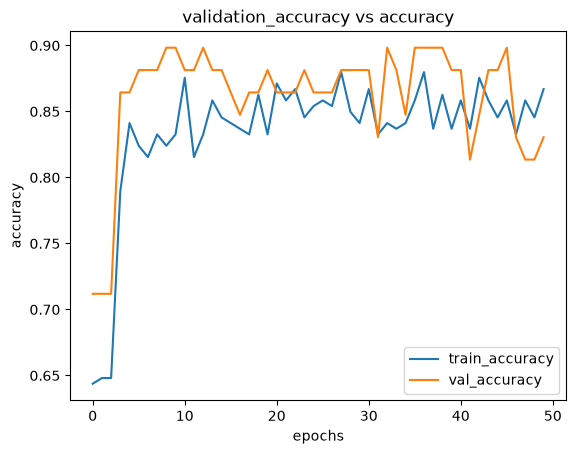

In [41]:
plt.plot(history.history['accuracy'],label='train_accuracy')
plt.plot(history.history['val_accuracy'],label='val_accuracy')
plt.title('validation_accuracy vs accuracy')
plt.xlabel('epochs')
plt.ylabel('accuracy')
plt.legend()
plt.show()

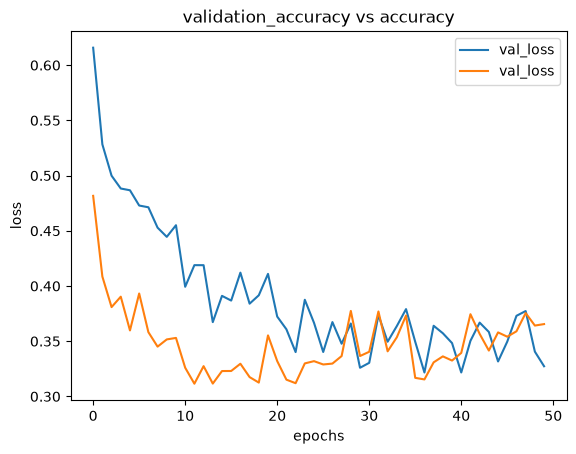

In [42]:
plt.plot(history.history['loss'],label='val_loss')
plt.plot(history.history['val_loss'],label='val_loss')
plt.title('validation_accuracy vs accuracy')
plt.xlabel('epochs')
plt.ylabel('loss')
plt.legend()
plt.show()

In [40]:
X_train.shape

(292, 10)